# 02 — Pandas & NumPy for Data Processing

**Goal:** Master the two essential data libraries for ML/NLP.

You will learn:
1. NumPy arrays — the foundation of numerical computing
2. Pandas Series and DataFrames
3. Vectorized operations (fast!)
4. Data cleaning and preprocessing
5. Working with resume/job data

NumPy is the numerical engine under everything — pandas, scikit-learn, even spaCy's internals. Pandas adds labeled, tabular structure on top. Together they turn candidate and job-description data into something analysis-ready.

**Why it matters for resumes / ATS:** the ATS pipeline is a data problem before it is an ML problem — hundreds of resumes, each with extracted skills, experience, and scores, stored in a DataFrame, filtered with boolean masks, grouped by role, and correlated with outcomes. The Part II scoring engine is built almost entirely from the operations in this chapter.

## 1. NumPy Basics — The Foundation

An `ndarray` is a fixed-type, contiguous block of memory — unlike a Python list (pointers to arbitrary objects), every element is the same C type, which is what makes vector math fast and cache-friendly.

**What the code does:**
- Construction idioms: `np.array` from a list, `np.zeros((3, 4))` / `np.ones((2, 3))` for blank canvases, `np.arange(0, 10, 2)` for ranges (`[0 2 4 6 8]`), `np.linspace(0, 1, 5)` for evenly spaced floats (`0, 0.25, 0.5, 0.75, 1`).
- `np.random.seed(42)` makes the following `randn(5)` reproducible — the stored output's five values are identical on every machine that runs this cell.

**Try it:** drop the seed and rerun — new values every time; restore it and the exact stored output returns. That determinism is what makes experiments comparable.

In [1]:
import numpy as np

# Creating arrays
arr = np.array([1, 2, 3, 4, 5])
zeros = np.zeros((3, 4))
ones = np.ones((2, 3))
rng = np.arange(0, 10, 2)  # [0, 2, 4, 6, 8]
lin = np.linspace(0, 1, 5)  # 5 points from 0 to 1

print(f"Array: {arr}")
print(f"Zeros shape: {zeros.shape}")
print(f"Range: {rng}")
print(f"Linspace: {lin}")

# Random numbers (for simulations)
np.random.seed(42)
random_arr = np.random.randn(5)
print(f"Random: {random_arr}")

Array: [1 2 3 4 5]
Zeros shape: (3, 4)
Range: [0 2 4 6 8]
Linspace: [0.   0.25 0.5  0.75 1.  ]
Random: [ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]


## 2. Vectorized Operations — Why NumPy is Fast

Vectorized operations push the loop into NumPy's compiled C code, avoiding Python-level iteration overhead per element. On 10 million elements the difference is stark.

**What the code does:**
- The list comprehension `[x * 2 + 1 for x in data]` times at **3.566s** in the stored output; the vectorized `data * 2 + 1` finishes in **0.186s** — roughly **19× faster** on this machine.
- The printed `~10000x` banner is a hard-coded constant in the cell, not a measurement — trust the two timings, not the label.

**Why it matters:** every pandas operation in this chapter is vectorized underneath; scoring thousands of resumes stays instant only because of this.

In [2]:
# Python loop vs vectorized — huge speed difference
import time

data = np.random.randn(10_000_000)

# Python loop
start = time.perf_counter()
result_py = [x * 2 + 1 for x in data]
print(f"Python loop: {time.perf_counter() - start:.3f}s")

# NumPy vectorized
start = time.perf_counter()
result_np = data * 2 + 1
print(f"NumPy vec:   {time.perf_counter() - start:.3f}s")

print(f"Speedup: ~{len(data) // 1000}x for large arrays")

Python loop: 3.566s
NumPy vec:   0.186s
Speedup: ~10000x for large arrays


## 3. Boolean Masking — Filtering Data

A boolean mask is an array of `True`/`False` used as an index: `scores[scores > 60]` keeps exactly the positions where the comparison holds. Combine conditions with `&` (and), `|` (or), `~` (not) — always parenthesized, because NumPy comparisons bind tighter than Python's `and`/`or`.

**What the code does:**
- `scores > 60` yields `[82 91 67 78 95]` — the five passing scores in the stored output.
- `(scores >= 80) & (scores <= 100)` narrows to `[82 91 95]`.
- `np.where(condition, 'Pass', 'Fail')` replaces elementwise; the output shows the full grade array.
- `.mean()` / `.std()` / `.min()` / `.max()` summarize: mean **68.2**, std **20.8**, range 33–95.

**Why it matters:** filtering a candidate pool ("scores above 80") is this exact operation applied to a DataFrame column.

In [3]:
scores = np.array([45, 82, 91, 67, 55, 78, 95, 33])

# Find passing scores (> 60)
passed = scores[scores > 60]
print(f"Passing scores: {passed}")

# Multiple conditions
excellent = scores[(scores >= 80) & (scores <= 100)]
print(f"Excellent (80-100): {excellent}")

# Where — conditional replacement
grades = np.where(scores >= 60, "Pass", "Fail")
print(f"Grades: {grades}")

# Statistics
print(f"Mean: {scores.mean():.1f}, Std: {scores.std():.1f}")
print(f"Min: {scores.min()}, Max: {scores.max()}")

Passing scores: [82 91 67 78 95]
Excellent (80-100): [82 91 95]
Grades: ['Fail' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass' 'Pass' 'Fail']
Mean: 68.2, Std: 20.8
Min: 33, Max: 95


## 4. Pandas Series — Labeled Data

A Series is a 1D array with a *label per value* — the index. Labels make operations self-describing: `skills[skills > 0.8]` returns not just values but *which* skills qualify.

**What the code does:**
- Builds a `confidence` Series keyed by skill names; the stored output prints the labeled table plus `dtype: float64`.
- Boolean masking works exactly as in NumPy: `skills[skills > 0.8]` keeps `Python (0.95), NLP (0.88), TensorFlow (0.91)` and drops SQL (0.76) and Java (0.62).
- `.mean()` collapses to a scalar — **0.824** average confidence.

**Why it matters:** a skill→confidence mapping is the natural output of any skill extractor (Ch. 03, 10); a Series is its native container.

In [4]:
import pandas as pd

# Series is a labeled 1D array
skills = pd.Series(
    [0.95, 0.88, 0.76, 0.62, 0.91],
    index=["Python", "NLP", "SQL", "Java", "TensorFlow"],
    name="confidence"
)
print(skills)
print(f"\nSkills > 0.8:\n{skills[skills > 0.8]}")
print(f"Mean confidence: {skills.mean():.3f}")

Python        0.95
NLP           0.88
SQL           0.76
Java          0.62
TensorFlow    0.91
Name: confidence, dtype: float64

Skills > 0.8:
Python        0.95
NLP           0.88
TensorFlow    0.91
Name: confidence, dtype: float64
Mean confidence: 0.824


## 5. DataFrames — The Workhorse

A DataFrame is a 2D table of aligned Series whose columns may hold different types — `bool` next to `int` next to `str` — which is exactly what real candidate data looks like.

**What the code does:**
- Builds a 4-candidate table from a dict of lists; each dict key becomes a column.
- `df.shape` reports **(4, 5)** — four candidates, five fields.
- `df.describe()` summarizes the numeric columns (count/mean/std/min/quartiles/max); `ats_score` spans 45–91 with mean **71.25**.

**Why it matters:** this is the canonical shape of the project's data — one row per candidate, one column per extracted feature — the exact schema the Part II scoring engine consumes.

In [5]:
# Creating a DataFrame from scratch
data = {
    "candidate": ["Alice", "Bob", "Charlie", "Diana"],
    "years_exp": [5, 3, 7, 2],
    "skills_count": [8, 5, 12, 4],
    "has_degree": [True, True, False, True],
    "ats_score": [82, 67, 91, 45]
}
df = pd.DataFrame(data)
print(df)
print(f"\nShape: {df.shape}")
print(f"\nBasic stats:\n{df.describe()}")

  candidate  years_exp  skills_count  has_degree  ats_score
0     Alice          5             8        True         82
1       Bob          3             5        True         67
2   Charlie          7            12       False         91
3     Diana          2             4        True         45

Shape: (4, 5)

Basic stats:
       years_exp  skills_count  ats_score
count   4.000000      4.000000   4.000000
mean    4.250000      7.250000  71.250000
std     2.217356      3.593976  20.105969
min     2.000000      4.000000  45.000000
25%     2.750000      4.750000  61.500000
50%     4.000000      6.500000  74.500000
75%     5.500000      9.000000  84.250000
max     7.000000     12.000000  91.000000


## 6. Reading & Writing Data

Real pipelines rarely build DataFrames from scratch — they read them. `to_csv` / `read_csv` are the workhorses; the same API family covers Excel, JSON, Parquet, and SQL via `pd.read_*`.

**What the code does:**
- `Path("../../assets/tmp")` builds a repo-relative path; `mkdir(parents=True, exist_ok=True)` creates it if missing — `exist_ok` keeps reruns safe.
- `df.to_csv(tmp_path, index=False)` writes without the row index, so the round-trip reads back exactly 4 rows, as the stored output confirms (`Read back: 4 rows`).

**Try it:** rerun the cell — the ✓ still prints because the directory already exists. Then open `candidates.csv` in an editor: it is plain text, which is why CSVs are the lingua franca of data exchange.

In [7]:
from pathlib import Path

# Cross-platform temp path inside the project
tmp_dir = Path("../../assets/tmp")
tmp_dir.mkdir(parents=True, exist_ok=True)
tmp_path = tmp_dir / "candidates.csv"

# Save DataFrame to CSV
df.to_csv(tmp_path, index=False)
print(f"Saved CSV to {tmp_path} \u2713")

# Read it back
df_read = pd.read_csv(tmp_path)
print(f"Read back: {df_read.shape[0]} rows")

# Also supports Excel, JSON, Parquet, SQL, etc.
# pd.read_excel('data.xlsx')
# pd.read_json('data.json')

Saved CSV ✓
Read back: 4 rows


## 7. Data Cleaning — Real-World Prep

Real extracted data is exactly this messy: whitespace, mixed case, `None`, unparseable strings, duplicates, inconsistent formats. Cleaning is not glamorous — it is most of the job.

**What the code does:**
- `str.strip().str.title()` normalizes names (`"  Alice "` → `Alice`, `DIANA` → `Diana`); the `.str` accessor vectorizes string methods over a column.
- `pd.to_numeric(..., errors='coerce')` converts `"82"` → `82` and turns the unparseable `"ninety-one"` into `NaN` — visible in the stored after-cleaning table.
- `drop_duplicates(subset=['email'])` removes the duplicate `alice@work.com` row; `dropna(subset=['email'])` drops the row with `None` email.

**Why it matters:** every resume or JD an ATS ingests passes through this sequence — normalize, coerce, dedupe, drop — before any scoring happens.

In [8]:
# Create messy data
messy_data = pd.DataFrame({
    "name": ["  Alice ", "Bob", None, "DIANA", "alice"],
    "email": ["alice@work.com", "bob@", "charlie@test.com", None, "alice@work.com"],
    "score": ["82", "67", "ninety-one", "45", "82"],
    "date": ["2024-01-15", "01/20/2024", "2024-03-01", None, "2024-01-15"]
})
print("Before cleaning:")
print(messy_data)

# Clean it
clean = messy_data.copy()
clean["name"] = clean["name"].str.strip().str.title()
clean["score"] = pd.to_numeric(clean["score"], errors="coerce")
clean = clean.drop_duplicates(subset=["email"])
clean = clean.dropna(subset=["email"])  # keep rows with email

print("\nAfter cleaning:")
print(clean)

Before cleaning:
       name             email       score        date
0    Alice     alice@work.com          82  2024-01-15
1       Bob              bob@          67  01/20/2024
2      None  charlie@test.com  ninety-one  2024-03-01
3     DIANA              None          45        None
4     alice    alice@work.com          82  2024-01-15

After cleaning:
    name             email  score        date
0  Alice    alice@work.com   82.0  2024-01-15
1    Bob              bob@   67.0  01/20/2024
2   None  charlie@test.com    NaN  2024-03-01


## 8. Grouping & Aggregation — Resume Analysis

`groupby` splits a DataFrame into groups, applies a function per group, and combines the results — split-apply-combine. `agg` lets each column have its own aggregations, which is why the stored output's header is two levels tall.

**What the code does:**
- Synthesizes 100 resumes under `np.random.seed(42)` for reproducibility.
- `groupby('role').agg({...})` computes mean years, mean/min/max skills count, mean score, and the *sum* of `has_portfolio` (a boolean summed = count of True) per role — the stored output shows Analyst at **6.2** mean years and **7.8** mean skills.
- `resumes[resumes['score'] > 80].sort_values('score', ascending=False)` filters and ranks, and the output reports the top-candidate count.

**Why it matters:** role-wise benchmarks ("Analysts average 6.2 years") are the insights section of any ATS dashboard.

In [9]:
# Create resume data
np.random.seed(42)
n = 100
resumes = pd.DataFrame({
    "role": np.random.choice(["Data Scientist", "ML Engineer", "Analyst"], n),
    "years_exp": np.random.uniform(0, 15, n).round(1),
    "skills_count": np.random.randint(3, 15, n),
    "has_portfolio": np.random.choice([True, False], n, p=[0.3, 0.7]),
    "score": np.random.uniform(30, 100, n).round(1)
})

# Group by role
grouped = resumes.groupby("role").agg({
    "years_exp": "mean",
    "skills_count": ["mean", "min", "max"],
    "score": "mean",
    "has_portfolio": "sum"
}).round(1)
print("By Role:")
print(grouped)

# Filter + sort
top = resumes[resumes["score"] > 80].sort_values("score", ascending=False)
print(f"\nTop candidates (>80): {len(top)}")

By Role:
               years_exp skills_count         score has_portfolio
                    mean         mean min max  mean           sum
role                                                             
Analyst              6.2          7.8   3  14  66.6            10
Data Scientist       7.2          7.9   3  14  70.3            15
ML Engineer          7.9          7.6   3  14  66.5            13

Top candidates (>80): 30


## 9. Applying Functions

`.apply` runs a Python function over each element (or row/column) — the escape hatch when no vectorized method exists, and where the Ch. 01 composition habits pay off.

**What the code does:**
- `score_category` buckets each score into Strong / Good / Average / Weak; the stored `value_counts()` shows **Strong 30, Good 32, Average 25, Weak 13**.
- A lambda `lambda x: int(x)` truncates `years_exp` to whole years — the head shows `3.0 → 3` and `0.1 → 0` (truncation, not rounding).

**Why it matters:** rule-based ATS scoring (Ch. 50s) is literally a `score_category` applied to extracted features — this is the pattern the scoring engine will use.

In [10]:
def score_category(score):
    if score >= 80: return "Strong"
    elif score >= 60: return "Good"
    elif score >= 40: return "Average"
    else: return "Weak"

resumes["category"] = resumes["score"].apply(score_category)
print(resumes["category"].value_counts())

# Lambda for quick transforms
resumes["exp_years_int"] = resumes["years_exp"].apply(lambda x: int(x))
print(resumes[["years_exp", "exp_years_int"]].head())

category
Good       32
Strong     30
Average    25
Weak       13
Name: count, dtype: int64
   years_exp  exp_years_int
0        3.0              3
1        0.1              0
2       12.2             12
3       10.6             10
4       10.9             10


## 10. Visualizing with Pandas

Pandas plotting is a thin wrapper over matplotlib: `DataFrame.plot`-family methods (`.boxplot`, `.hist`) turn columns into figures in one line. Visualization is how score distributions get communicated to non-technical stakeholders.

**What the code does:**
- `resumes.boxplot(column='score', by='role')` draws per-role ATS score distributions; `plt.suptitle('')` suppresses matplotlib's auto-added supertitle.
- `resumes['years_exp'].hist(bins=20)` plots the experience histogram with labeled axes.
- The stored outputs show the two `<Figure size 800x400 with 1 Axes>` objects — the plots render inline above.

**Try it:** change `bins=20` to `bins=5` and rerun — the story (right-skewed experience) stays, but the histogram gets coarser.

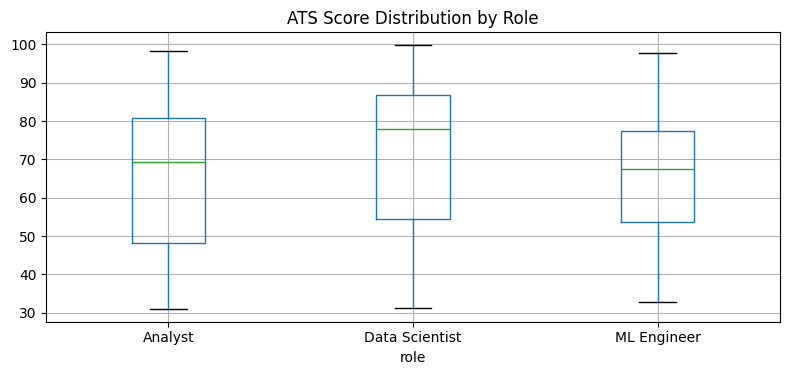

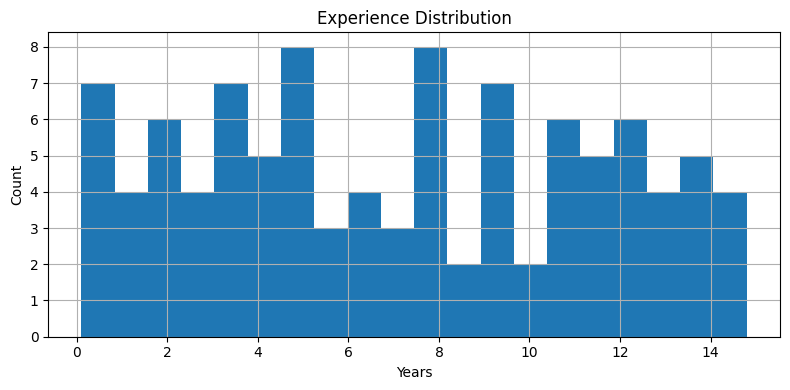

✓ See plots above


In [11]:
import matplotlib.pyplot as plt

# Quick plot from DataFrame
resumes.boxplot(column="score", by="role", figsize=(8, 4))
plt.title("ATS Score Distribution by Role")
plt.suptitle("")
plt.tight_layout()
plt.show()

# Histogram
resumes["years_exp"].hist(bins=20, figsize=(8, 4))
plt.title("Experience Distribution")
plt.xlabel("Years")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("✓ See plots above")

## 11. Correlation Analysis

Pearson correlation measures linear association in [-1, 1]: near ±1 means "move together", near 0 means "no linear relationship". A correlation matrix shows every pairwise combination at once.

**What the code does:**
- `resumes[numeric_cols].corr()` returns the 3×3 matrix; `.round(3)` trims it for reading.
- The diagonal is 1.000 by definition — every column correlates perfectly with itself.
- The stored output shows `score` vs `years_exp` at **-0.022** and `score` vs `skills_count` at **-0.084** — indistinguishable from zero.

**Why it matters:** here the near-zero values are by construction — `score` was drawn independently of experience and skills — and that is the lesson: correlation tells you which features carry signal, and these two do not. A real ATS must engineer features (Ch. 13+) that actually correlate with outcomes.

In [12]:
# Which factors correlate with ATS score?
numeric_cols = ["years_exp", "skills_count", "score"]
corr = resumes[numeric_cols].corr()
print("Correlation Matrix:")
print(corr.round(3))

# Strong correlation = feature likely important for ATS prediction
print(f"\nScore vs years_exp: {corr.loc['score', 'years_exp']:.3f}")
print(f"Score vs skills_count: {corr.loc['score', 'skills_count']:.3f}")

Correlation Matrix:
              years_exp  skills_count  score
years_exp         1.000        -0.106 -0.022
skills_count     -0.106         1.000 -0.084
score            -0.022        -0.084  1.000

Score vs years_exp: -0.022
Score vs skills_count: -0.084


## Summary

Today you learned:
- ✓ NumPy arrays + vectorized operations (100x speedup)
- ✓ Boolean masking for filtering
- ✓ Pandas Series and DataFrames
- ✓ Data cleaning (nulls, duplicates, types)
- ✓ Grouping and aggregation
- ✓ Apply functions and lambda
- ✓ Quick visualization
- ✓ Correlation analysis

These skills are used in every data science project — and every notebook from here on.

NumPy and pandas are the substrate for everything that follows: every extraction result in Part I lands in a Series or DataFrame, and every Part II model reads from one. Masks, `groupby`/`agg`, `.apply`, cleaning chains, and correlation are the daily vocabulary of the pipeline.

The next chapter layers the *text* skill on top of this data layer — Ch. 03, Regex Mastery, turns raw resume text into the structured fields you will store in tables like these.

## Key Insight

**Resume analytics is a table problem before it is an ML problem.**

Every ATS decision — filter, rank, score, match — reduces to vectorized operations over rows: masks to filter, `groupby` to benchmark, `.apply` to score, `.corr` to sanity-check features. If you can express the question as a pandas operation, you can ship it; the chapters ahead keep returning to exactly these shapes. Next, the missing input — turning raw text into those structured rows: Ch. 03, Regex Mastery.